In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [3]:
df = pd.read_csv('titanic_toy.csv')

In [4]:
df.head()

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


In [5]:
df.isnull().sum()

Age         177
Fare         45
Family        0
Survived      0
dtype: int64

In [7]:
x = df.drop(columns=['Survived'])
y = df['Survived']
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=2)

<h1>Using Pandas</h1>

In [8]:
age_end=x_train['Age'].mean()+3*x_train['Age'].std()
fare_end=x_train['Fare'].mean()+3*x_train['Fare'].std()

In [9]:
x_train['Age_end_dist']=x_train['Age'].fillna(age_end)
x_train['Fare_end_dist']=x_train['Fare'].fillna(fare_end)

In [15]:
x_train.sample(5)

,Age,Fare,Family,Age_end_dist,Fare_end_dist
145,19.0,36.7500,2,19.0,36.750000
327,36.0,NaN,0,36.0,181.055399
605,36.0,15.5500,1,36.0,15.550000
416,34.0,32.5000,2,34.0,32.500000
710,24.0,49.5042,0,24.0,49.504200


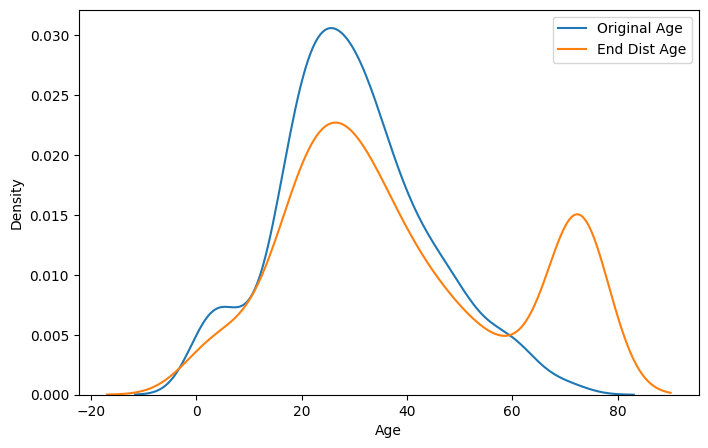

In [10]:
plt.figure(figsize=(8,5))

sns.kdeplot(x_train['Age'], label='Original Age')
sns.kdeplot(x_train['Age_end_dist'], label='End Dist Age')

plt.legend()

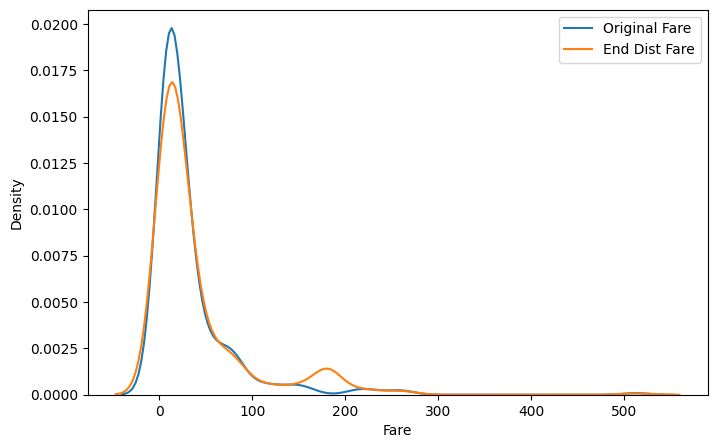

In [11]:
plt.figure(figsize=(8,5))

sns.kdeplot(x_train['Fare'], label='Original Fare')
sns.kdeplot(x_train['Fare_end_dist'], label='End Dist Fare')

plt.legend()

<h1>Using Sklearn</h1>

In [16]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=2)

In [17]:
age_imputer=SimpleImputer(strategy='constant',fill_value=age_end)
fare_imputer=SimpleImputer(strategy='constant',fill_value=fare_end)
trf=ColumnTransformer([
    ('age_imputer',age_imputer,['Age']),
    ('fare_imputer',fare_imputer,['Fare'])
],remainder='passthrough')

In [18]:
x_train_trf=trf.fit_transform(x_train)
x_test_trf=trf.transform(x_test)

In [19]:
x_train_trf

array([[ 40.        ,  27.7208    ,   0.        ],
       [  4.        ,  16.7       ,   2.        ],
       [ 47.        ,   9.        ,   0.        ],
       ...,
       [ 71.        ,  49.5042    ,   0.        ],
       [ 72.67116537, 221.7792    ,   0.        ],
       [ 72.67116537,  25.925     ,   0.        ]], shape=(712, 3))

In [20]:
x_train_trf=pd.DataFrame(x_train_trf,columns=x_train.columns)
x_train_trf

,Age,Fare,Family
0,40.000000,27.7208,0.0
1,4.000000,16.7000,2.0
2,47.000000,9.0000,0.0
3,9.000000,31.3875,6.0
4,20.000000,9.8458,0.0
...,...,...,...
707,30.000000,8.6625,0.0
708,72.671165,8.7125,0.0
709,71.000000,49.5042,0.0
710,72.671165,221.7792,0.0


In [21]:
x_train_trf.isnull().sum()

Age       0
Fare      0
Family    0
dtype: int64